# Training, Evaluation, and Error Analysis

This notebook can run the expensive stages when requested, but its default mode
loads the results created by the Python scripts. This is convenient for the
demonstration video and avoids accidental retraining.

In [1]:
from pathlib import Path
import sys
import json
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, Image

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.baseline import run_baseline
from src.config import FIGURE_DIR, METRICS_DIR
from src.evaluate import evaluate_model
from src.train import train_model

## 1. Traditional baseline

TF-IDF with Logistic Regression provides a non-Transformer comparison. Set the flag to `True` only when the baseline has not already been run.

In [2]:
RUN_BASELINE = False
if RUN_BASELINE:
    baseline_results = run_baseline()
    display(baseline_results)
elif (METRICS_DIR / 'baseline_metrics.json').exists():
    with open(METRICS_DIR / 'baseline_metrics.json', encoding='utf-8') as file:
        display(json.load(file))
else:
    print('Run: python -m src.baseline')

{'model': 'TF-IDF + Logistic Regression',
 'max_features': 30000,
 'validation': {'accuracy': 0.9194961207975306,
  'macro_precision': 0.9193820585644583,
  'macro_recall': 0.9194858960405667,
  'macro_f1': 0.9192973392988235,
  'weighted_f1': 0.9193080841486387},
 'test': {'accuracy': 0.9182894736842105,
  'macro_precision': 0.9180788327260057,
  'macro_recall': 0.9182894736842104,
  'macro_f1': 0.9181055969640975,
  'weighted_f1': 0.9181055969640975}}

## 2. Fine-tune DistilBERT

The training function uses the complete dataset, a manual PyTorch loop, cross-entropy loss, AdamW, a linear learning-rate schedule, gradient clipping, checkpointing, and early stopping. Long training is more reliable from the terminal with `python -m src.train`.

In [3]:
RUN_FULL_TRAINING_IN_NOTEBOOK = False
if RUN_FULL_TRAINING_IN_NOTEBOOK:
    training_history = train_model()
    display(training_history)
else:
    print('Training is disabled in the notebook. Run: python -m src.train')

Training is disabled in the notebook. Run: python -m src.train


## 3. Learning curves and overfitting check

Overfitting is suggested when training loss continues falling while validation loss rises, or when the training-validation accuracy gap becomes large. The best checkpoint is selected using the lowest validation loss.

,epoch,train_loss,train_accuracy,train_macro_f1,validation_loss,validation_accuracy,validation_macro_f1
0,1,0.2841,0.9006,0.9010,0.1913,0.9393,0.9394
1,2,0.1492,0.9544,0.9544,0.1981,0.9440,0.9440
2,3,0.0999,0.9712,0.9712,0.2194,0.9447,0.9447


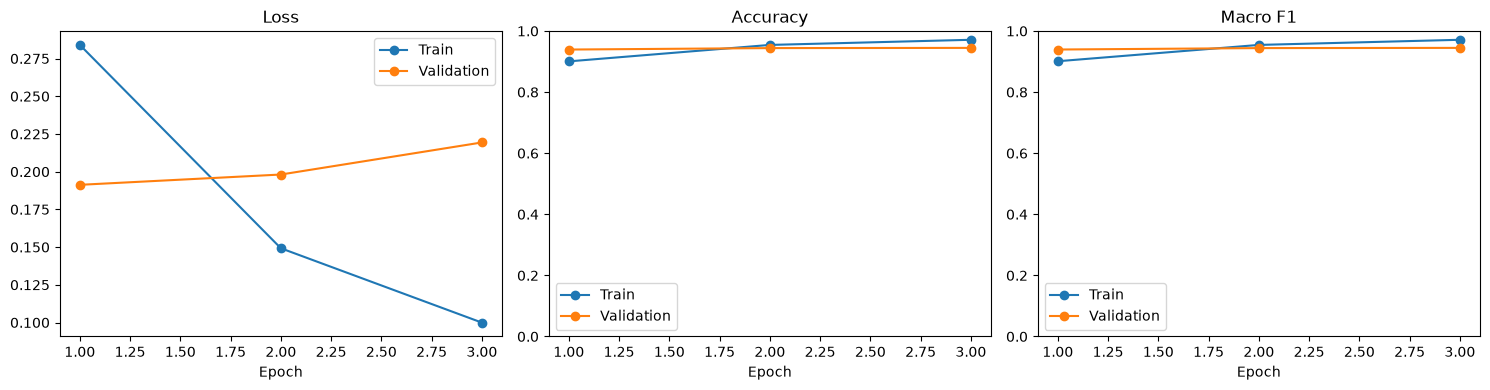

Best validation-loss epoch: 1
Final training-validation accuracy gap: 0.0265
Interpretation: the final epoch shows a possible overfitting pattern.


In [4]:
history_path = METRICS_DIR / 'training_history.csv'
if history_path.exists():
    history = pd.read_csv(history_path)
    display(history.round(4))

    figure, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(history['epoch'], history['train_loss'], marker='o', label='Train')
    axes[0].plot(history['epoch'], history['validation_loss'], marker='o', label='Validation')
    axes[0].set_title('Loss')
    axes[0].legend()

    axes[1].plot(history['epoch'], history['train_accuracy'], marker='o', label='Train')
    axes[1].plot(history['epoch'], history['validation_accuracy'], marker='o', label='Validation')
    axes[1].set_title('Accuracy')
    axes[1].set_ylim(0, 1)
    axes[1].legend()

    axes[2].plot(history['epoch'], history['train_macro_f1'], marker='o', label='Train')
    axes[2].plot(history['epoch'], history['validation_macro_f1'], marker='o', label='Validation')
    axes[2].set_title('Macro F1')
    axes[2].set_ylim(0, 1)
    axes[2].legend()
    for axis in axes:
        axis.set_xlabel('Epoch')
    plt.tight_layout()
    plt.show()

    best_row = history.loc[history['validation_loss'].idxmin()]
    last_row = history.iloc[-1]
    accuracy_gap = last_row['train_accuracy'] - last_row['validation_accuracy']
    print(f"Best validation-loss epoch: {int(best_row['epoch'])}")
    print(f"Final training-validation accuracy gap: {accuracy_gap:.4f}")
    if len(history) > 1 and last_row['validation_loss'] > best_row['validation_loss'] and last_row['train_loss'] < history.iloc[-2]['train_loss']:
        print('Interpretation: the final epoch shows a possible overfitting pattern.')
    else:
        print('Interpretation: no clear final-epoch overfitting pattern from loss alone.')
else:
    print('No training history yet. Train the model first.')

## 4. Test evaluation

Evaluation loads the best saved checkpoint and uses the untouched official test set. It does not retrain the model.

In [5]:
RUN_EVALUATION_IN_NOTEBOOK = False
if RUN_EVALUATION_IN_NOTEBOOK:
    evaluation_results = evaluate_model()
    display(evaluation_results)
else:
    print('Evaluation is disabled in the notebook. Run: python -m src.evaluate')

Evaluation is disabled in the notebook. Run: python -m src.evaluate


accuracy           0.9392
macro_precision    0.9394
macro_recall       0.9392
macro_f1           0.9393
weighted_f1        0.9393
Name: Test result, dtype: float64

,precision,recall,f1-score,support
World,0.9609,0.9447,0.9528,1900.0000
Sports,0.9843,0.9879,0.9861,1900.0000
Business,0.9052,0.9047,0.9050,1900.0000
Sci/Tech,0.9071,0.9195,0.9132,1900.0000
accuracy,0.9392,0.9392,0.9392,0.9392
macro avg,0.9394,0.9392,0.9393,7600.0000
weighted avg,0.9394,0.9392,0.9393,7600.0000


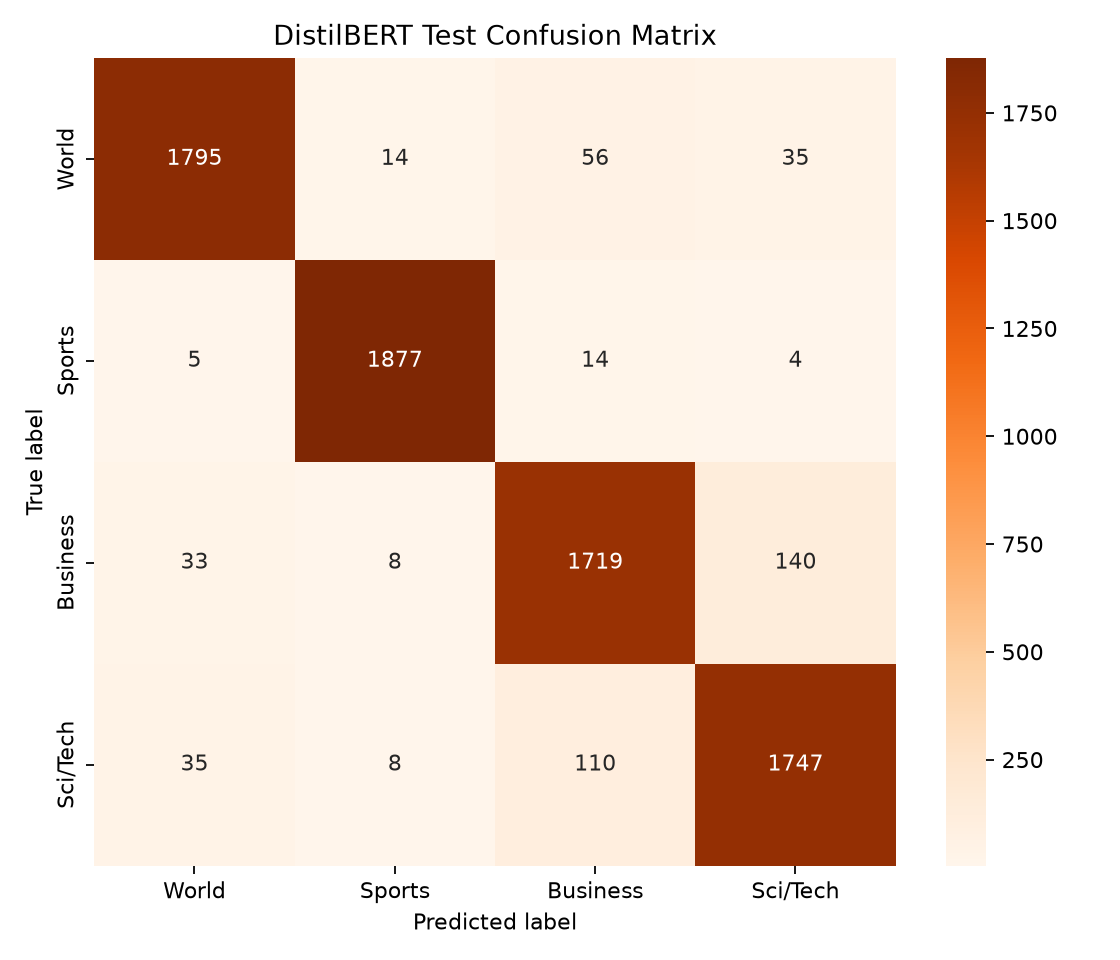

In [6]:
metrics_path = METRICS_DIR / 'transformer_metrics.json'
report_path = METRICS_DIR / 'transformer_report.csv'
if metrics_path.exists():
    with open(metrics_path, encoding='utf-8') as file:
        display(pd.Series(json.load(file), name='Test result').round(4))
    display(pd.read_csv(report_path, index_col=0).round(4))
    display(Image(filename=str(FIGURE_DIR / 'transformer_confusion_matrix.png')))
else:
    print('No test metrics yet. Evaluate the saved model first.')

## 5. Baseline comparison and representative error analysis

The evaluation script saves all incorrect predictions. It then selects 20
examples approximately in proportion to the observed confusion-pair frequencies
and spreads them across the confidence range. This is more representative than
showing only the most confident mistakes.

In [7]:
comparison_path = METRICS_DIR / 'model_comparison.csv'
errors_path = METRICS_DIR / 'error_analysis_20.csv'
error_summary_path = METRICS_DIR / 'error_pattern_summary.json'

if comparison_path.exists():
    print('Model comparison')
    comparison = pd.read_csv(comparison_path)
    display(comparison.round(4))

if error_summary_path.exists():
    print('Error-pattern summary')
    with open(error_summary_path, encoding='utf-8') as file:
        error_summary = json.load(file)
    display(pd.Series(error_summary, name='Value'))

if errors_path.exists():
    errors = pd.read_csv(errors_path)

    def suggested_review_category(pair):
        if pair in {'Business -> Sci/Tech', 'Sci/Tech -> Business'}:
            return 'Business and technology vocabulary overlap'
        if pair in {'World -> Business', 'Business -> World'}:
            return 'International and economic context overlap'
        if 'Sports' in pair:
            return 'Sports wording, ownership, location, or named-entity issue'
        return 'Mixed topic, limited context, or possible label noise'

    errors['review_category'] = errors['confusion_pair'].map(suggested_review_category)
    print('Twenty representative errors')
    display_columns = [
        'text', 'true_label', 'predicted_label', 'confidence',
        'confidence_margin', 'word_count', 'confusion_pair', 'review_category'
    ]
    available_columns = [column for column in display_columns if column in errors.columns]
    display(errors[available_columns])
else:
    print('Run: python -m src.evaluate')

Model comparison


,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,TF-IDF + Logistic Regression,0.9183,0.9181,0.9183,0.9181,0.9181
1,DistilBERT,0.9392,0.9394,0.9392,0.9393,0.9393


Error-pattern summary


total_incorrect_predictions                                                           462
most_common_confusions                  {'Business -> Sci/Tech': 140, 'Sci/Tech -> Bus...
average_error_confidence                                                           0.8017
high_confidence_errors_at_least_0_80                                                  261
high_confidence_error_percentage                                                    56.49
business_sci_tech_errors                                                              250
business_sci_tech_error_percentage                                                  54.11
average_words_in_errors                                                             35.93
average_words_in_all_test_examples                                                  37.55
selected_error_method                   Proportional confusion-pair sample with confid...
Name: Value, dtype: object

Twenty representative errors


,text,true_label,predicted_label,confidence,confidence_margin,word_count,confusion_pair,review_category
0,Linux: Paris weighs a shift to open-source cam...,Business,Sci/Tech,0.993054,0.987145,47,Business -> Sci/Tech,Business and technology vocabulary overlap
1,"AOL, E-Mail Companies Sue Spammers The nation'...",Business,Sci/Tech,0.973408,0.948638,39,Business -> Sci/Tech,Business and technology vocabulary overlap
2,Broadband charges set to tumble The cost of br...,Business,Sci/Tech,0.920674,0.844382,28,Business -> Sci/Tech,Business and technology vocabulary overlap
3,IBM 'to sell PC business ' IBM is reportedly i...,Business,Sci/Tech,0.790082,0.582517,48,Business -> Sci/Tech,Business and technology vocabulary overlap
4,"Diesels, Hybrids Fated to Wed Two leading tech...",Business,Sci/Tech,0.638846,0.295106,39,Business -> Sci/Tech,Business and technology vocabulary overlap
5,Study raises stent doubts Heart patients aren'...,Business,Sci/Tech,0.461181,0.024574,31,Business -> Sci/Tech,Business and technology vocabulary overlap
6,A wandering Congress trips over the US Constit...,Business,World,0.443422,0.041650,46,Business -> World,International and economic context overlap
7,Gas prices up 5 cents after Hurricane Ivan CAM...,Sci/Tech,Business,0.996422,0.994216,38,Sci/Tech -> Business,Business and technology vocabulary overlap
8,An Unknown Giant Flexes Its Muscles Although v...,Sci/Tech,Business,0.897645,0.799336,34,Sci/Tech -> Business,Business and technology vocabulary overlap
9,Salesforce.com 2Q Profit Up Sharply Software d...,Sci/Tech,Business,0.760795,0.523663,35,Sci/Tech -> Business,Business and technology vocabulary overlap


## Final interpretation

The model learned quickly during training. Training loss decreased from **0.2841**
to **0.0999**, while training accuracy increased from **90.06%** to **97.12%**.
Validation accuracy also improved from **93.93%** to **94.47%**.

However, validation loss was lowest at **0.1913 in Epoch 1** and increased to
**0.2194 by Epoch 3**. This indicates mild overfitting because the model continued
improving on the training data while becoming more confident on some incorrect
validation predictions. Therefore, the Epoch 1 checkpoint was selected using
the lowest validation loss.

Training three epochs on an **NVIDIA RTX 4070 Laptop GPU** took approximately
**23 minutes and 48 seconds**.

On the official test split, which was not used for model training, DistilBERT
achieved **93.92% accuracy** and **93.93% macro F1**. The TF-IDF and Logistic
Regression baseline achieved **91.83% accuracy** and **91.81% macro F1**.
DistilBERT made **159 fewer mistakes**, representing a **25.6% reduction in
errors** compared with the baseline.

The main failure pattern was confusion between Business and Sci/Tech. These two
categories accounted for **250 of the 462 errors**, or **54.1% of all mistakes**.
Many technology articles also discuss companies, products, revenue, sales, and
market performance, making the correct category difficult to determine.

Other errors involved international economic events, incomplete or unclear
context, mixed-topic articles, and possible label ambiguity. Article length was
not the main issue because incorrect examples averaged **35.93 words**, compared
with **37.55 words** across the complete test set.

Overall, the model performed well. It correctly classified **7,138 of 7,600**
test articles and performed better than the traditional baseline. Possible
future improvements include reviewing ambiguous labels, adding more mixed-topic
examples, calibrating confidence scores, and comparing DistilBERT with another
pretrained Transformer model.
